In [1]:
import os, cv2, shutil, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
print("\n Upload your dataset ZIP file:")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
EXTRACT_PATH = '/content/traffic_data'

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(EXTRACT_PATH)

print(f" Extracted to: {EXTRACT_PATH}")

  PERSON 1 — DATASET COLLECTION & CLEANING

 Upload your dataset ZIP file:


Saving Traffic Sign.zip to Traffic Sign.zip
 Extracted to: /content/traffic_data


In [8]:
DATA_PATH = LABELS_PATH = TEST_PATH = None
for root, dirs, files_list in os.walk(EXTRACT_PATH):
    for d in dirs:
        if d.upper() == 'TRAIN':  DATA_PATH  = os.path.join(root, d)
        if d.upper() == 'TEST':   TEST_PATH   = os.path.join(root, d)
    for f in files_list:
        if f.endswith('.csv'):    LABELS_PATH = os.path.join(root, f)


if DATA_PATH is None:
    for root, dirs, _ in os.walk(EXTRACT_PATH):
        if dirs and all(d.isdigit() for d in dirs[:3]):
            DATA_PATH = root
            break

print(f"  DATA  : {DATA_PATH}")
print(f"  TEST  : {TEST_PATH}")
print(f"  LABELS: {LABELS_PATH}")

if LABELS_PATH:
    df_labels = pd.read_csv(LABELS_PATH)
    col_id, col_name = df_labels.columns[0], df_labels.columns[1]
    label_dict = dict(zip(df_labels[col_id], df_labels[col_name]))
    print(f"\n Loaded {len(label_dict)} class labels")
else:

    label_dict = {int(d): f"Class_{d}"
                  for d in os.listdir(DATA_PATH) if d.isdigit()}
    print(f"\n No CSV found — using {len(label_dict)} folder names as labels")


  DATA  : /content/traffic_data/traffic_Data/DATA
  TEST  : /content/traffic_data/traffic_Data/TEST
  LABELS: /content/traffic_data/labels.csv

 Loaded 58 class labels


   Valid images   : 4170
    Corrupted removed: 0


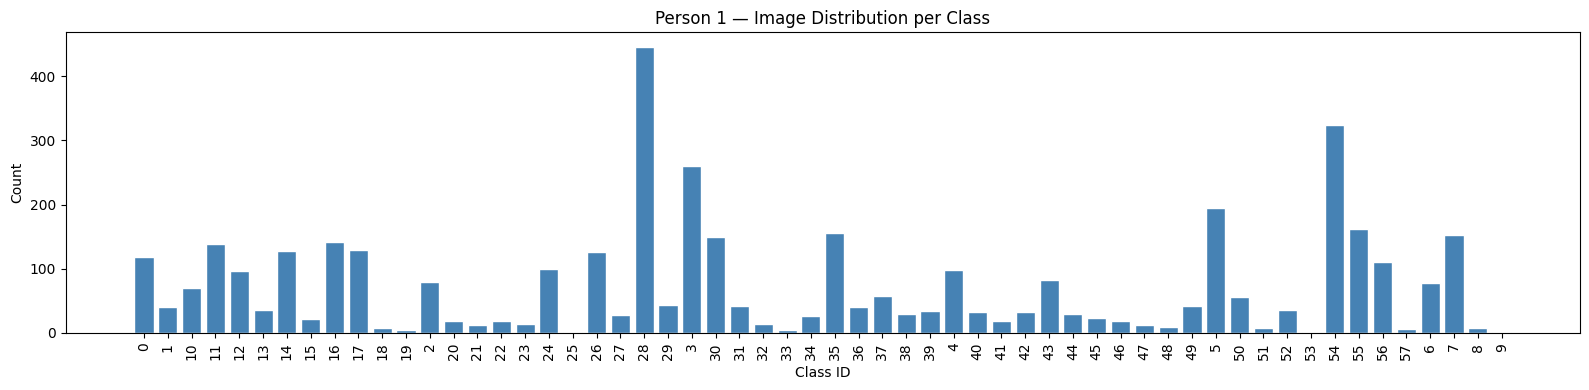

In [9]:
corrupted, valid = [], 0
for root, _, files_list in os.walk(DATA_PATH):
    for f in files_list:
        if f.lower().endswith(('.png','.jpg','.jpeg','.ppm')):
            path = os.path.join(root, f)
            img = cv2.imread(path)
            if img is None:
                corrupted.append(path)
                os.remove(path)
            else:
                valid += 1

print(f"   Valid images   : {valid}")
print(f"    Corrupted removed: {len(corrupted)}")


class_counts = {}
for cls in sorted(os.listdir(DATA_PATH)):
    p = os.path.join(DATA_PATH, cls)
    if os.path.isdir(p):
        imgs = [f for f in os.listdir(p)
                if f.lower().endswith(('.png','.jpg','.ppm'))]
        class_counts[cls] = len(imgs)

plt.figure(figsize=(16, 4))
plt.bar(class_counts.keys(), class_counts.values(),
        color='steelblue', edgecolor='white')
plt.xlabel('Class ID'); plt.ylabel('Count')
plt.title('Person 1 — Image Distribution per Class')
plt.xticks(rotation=90); plt.tight_layout()
plt.savefig('/content/P1_distribution.png', dpi=150)
plt.show()




In [11]:
IMG_SIZE = (64, 64)

def preprocess_image(img_path, img_size=IMG_SIZE):
    """Resize → Grayscale → Normalize → CLAHE Enhancement"""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None

    # 1. Resize
    resized = cv2.resize(img_bgr, img_size, interpolation=cv2.INTER_AREA)

    # 2. Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # 3. Normalize to [0, 1]
    normalized = gray.astype(np.float32) / 255.0

    # 4. CLAHE Enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    return {
        'color'     : cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
        'gray'      : gray,
        'normalized': normalized,
        'enhanced'  : enhanced,
        'original'  : cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
    }

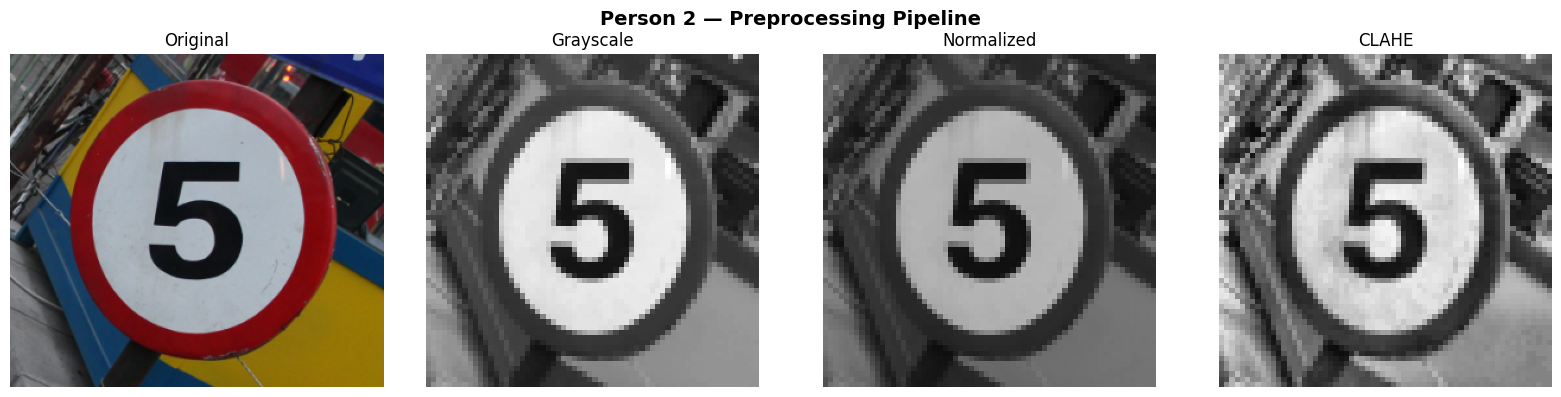

In [12]:
sample_cls  = sorted(os.listdir(DATA_PATH))[0]
sample_dir  = os.path.join(DATA_PATH, sample_cls)
sample_file = [f for f in os.listdir(sample_dir)
               if f.lower().endswith(('.png','.jpg','.ppm'))][0]
sample_path = os.path.join(sample_dir, sample_file)
r = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
stages = [('Original',   r['original'],   None),
          ('Grayscale',  r['gray'],        'gray'),
          ('Normalized', r['normalized'],  'gray'),
          ('CLAHE',      r['enhanced'],    'gray')]
for ax, (title, img, cmap) in zip(axes, stages):
    ax.imshow(img, cmap=cmap, vmin=0, vmax=(1 if cmap and img.max()<=1 else None))
    ax.set_title(title, fontsize=12); ax.axis('off')
plt.suptitle('Person 2 — Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/P2_preprocessing.png', dpi=150)
plt.show()

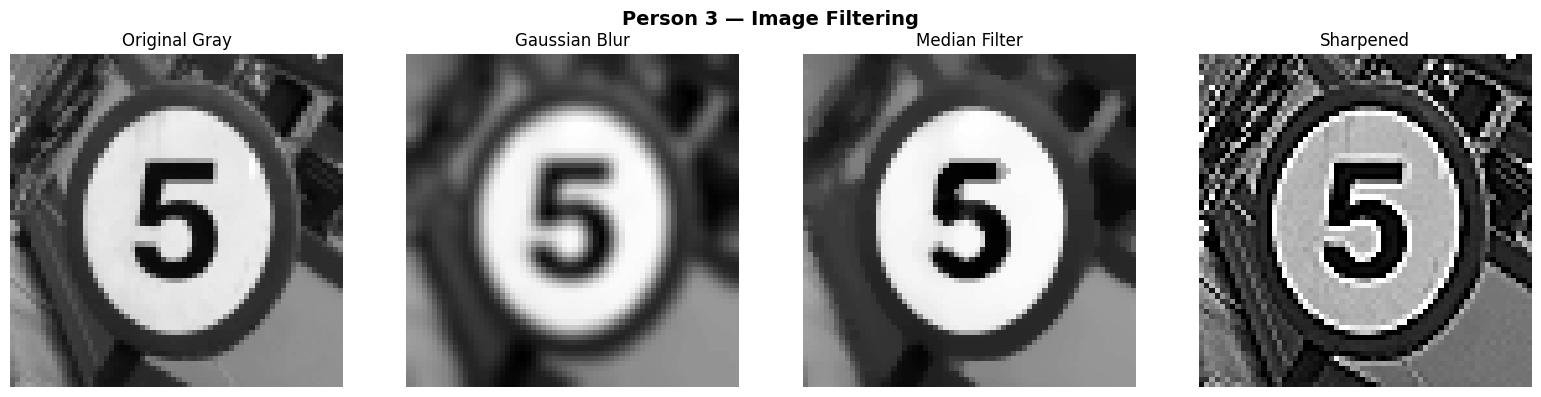

In [13]:
def apply_filters(gray_img):
    """Apply Gaussian blur, Median filter, and Sharpening"""

    # 1. Gaussian Blur — smooths noise
    gaussian = cv2.GaussianBlur(gray_img, (5, 5), sigmaX=1.5)

    # 2. Median Filter — removes salt-and-pepper noise
    median = cv2.medianBlur(gray_img, 5)

    # 3. Sharpening — enhances edges/details
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
    sharpened = cv2.filter2D(gray_img, -1, kernel)

    return {
        'original' : gray_img,
        'gaussian' : gaussian,
        'median'   : median,
        'sharpened': sharpened,
    }

gray_sample = r['gray']
filters = apply_filters(gray_sample)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
labels = ['Original Gray', 'Gaussian Blur', 'Median Filter', 'Sharpened']
for ax, (key, lbl) in zip(axes, zip(filters, labels)):
    ax.imshow(filters[key], cmap='gray')
    ax.set_title(lbl, fontsize=12); ax.axis('off')
plt.suptitle('Person 3 — Image Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/P3_filtering.png', dpi=150)
plt.show()

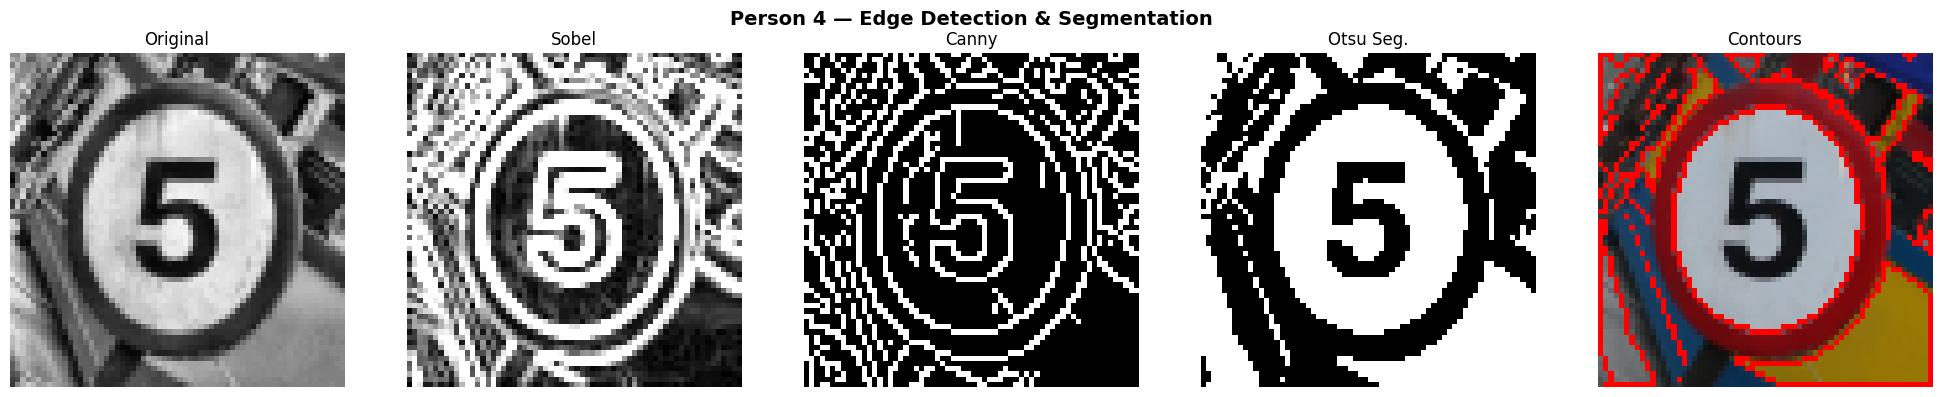

In [14]:
def edge_and_segment(gray_img, color_img):
    """Sobel, Canny edge detection + threshold segmentation"""

    # 1. Sobel — gradient-based edge detection
    sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    sobel   = cv2.magnitude(sobel_x, sobel_y)
    sobel   = np.uint8(np.clip(sobel, 0, 255))

    # 2. Canny — precise edge detection
    canny = cv2.Canny(gray_img, threshold1=50, threshold2=150)

    # 3. Otsu Thresholding — simple segmentation
    _, otsu = cv2.threshold(gray_img, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Contour overlay on color image
    contours, _ = cv2.findContours(otsu, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    contour_img = color_img.copy()
    cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 1)

    return {
        'original' : gray_img,
        'sobel'    : sobel,
        'canny'    : canny,
        'otsu'     : otsu,
        'contours' : contour_img,
    }

edges = edge_and_segment(r['enhanced'], r['color'])

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
items = [
    ('Original',   edges['original'],  'gray'),
    ('Sobel',      edges['sobel'],     'gray'),
    ('Canny',      edges['canny'],     'gray'),
    ('Otsu Seg.',  edges['otsu'],      'gray'),
    ('Contours',   edges['contours'],  None),
]
for ax, (title, img, cmap) in zip(axes, items):
    ax.imshow(img, cmap=cmap); ax.set_title(title, fontsize=12); ax.axis('off')
plt.suptitle('Person 4 — Edge Detection & Segmentation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/P4_edges_segmentation.png', dpi=150)
plt.show()

In [15]:
OUTPUT_DIR = '/content/processed_output'
for sub in ['preprocessed', 'filtered', 'edges']:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

meta = []
class_folders = [d for d in sorted(os.listdir(DATA_PATH))
                 if os.path.isdir(os.path.join(DATA_PATH, d))]

for cls in tqdm(class_folders, desc='Classes'):
    cls_path = os.path.join(DATA_PATH, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png','.jpg','.ppm'))]

    cls_id   = int(cls) if cls.isdigit() else -1
    cls_name = label_dict.get(cls_id, f'Class_{cls}')

    for img_file in img_files:
        path = os.path.join(cls_path, img_file)
        r2   = preprocess_image(path)
        if r2 is None:
            continue

        base = os.path.splitext(img_file)[0]

        # Save preprocessed (CLAHE)
        pre_dir = os.path.join(OUTPUT_DIR, 'preprocessed', cls)
        os.makedirs(pre_dir, exist_ok=True)
        cv2.imwrite(os.path.join(pre_dir, base + '_pre.png'), r2['enhanced'])

        # Save filtered (sharpened)
        flt = apply_filters(r2['gray'])
        flt_dir = os.path.join(OUTPUT_DIR, 'filtered', cls)
        os.makedirs(flt_dir, exist_ok=True)
        cv2.imwrite(os.path.join(flt_dir, base + '_sharp.png'), flt['sharpened'])

        # Save edge detection (Canny)
        edg = edge_and_segment(r2['enhanced'], r2['color'])
        edg_dir = os.path.join(OUTPUT_DIR, 'edges', cls)
        os.makedirs(edg_dir, exist_ok=True)
        cv2.imwrite(os.path.join(edg_dir, base + '_canny.png'), edg['canny'])

        meta.append({'class_id': cls_id, 'class_name': cls_name,
                     'file': img_file, 'size': f'{IMG_SIZE[0]}x{IMG_SIZE[1]}'})

# Save metadata CSV
df_meta = pd.DataFrame(meta)
df_meta.to_csv(os.path.join(OUTPUT_DIR, 'metadata.csv'), index=False)
print(f"\n Saved {len(meta)} images across 3 output folders")


Classes: 100%|██████████| 58/58 [00:15<00:00,  3.65it/s]


 Saved 4170 images across 3 output folders


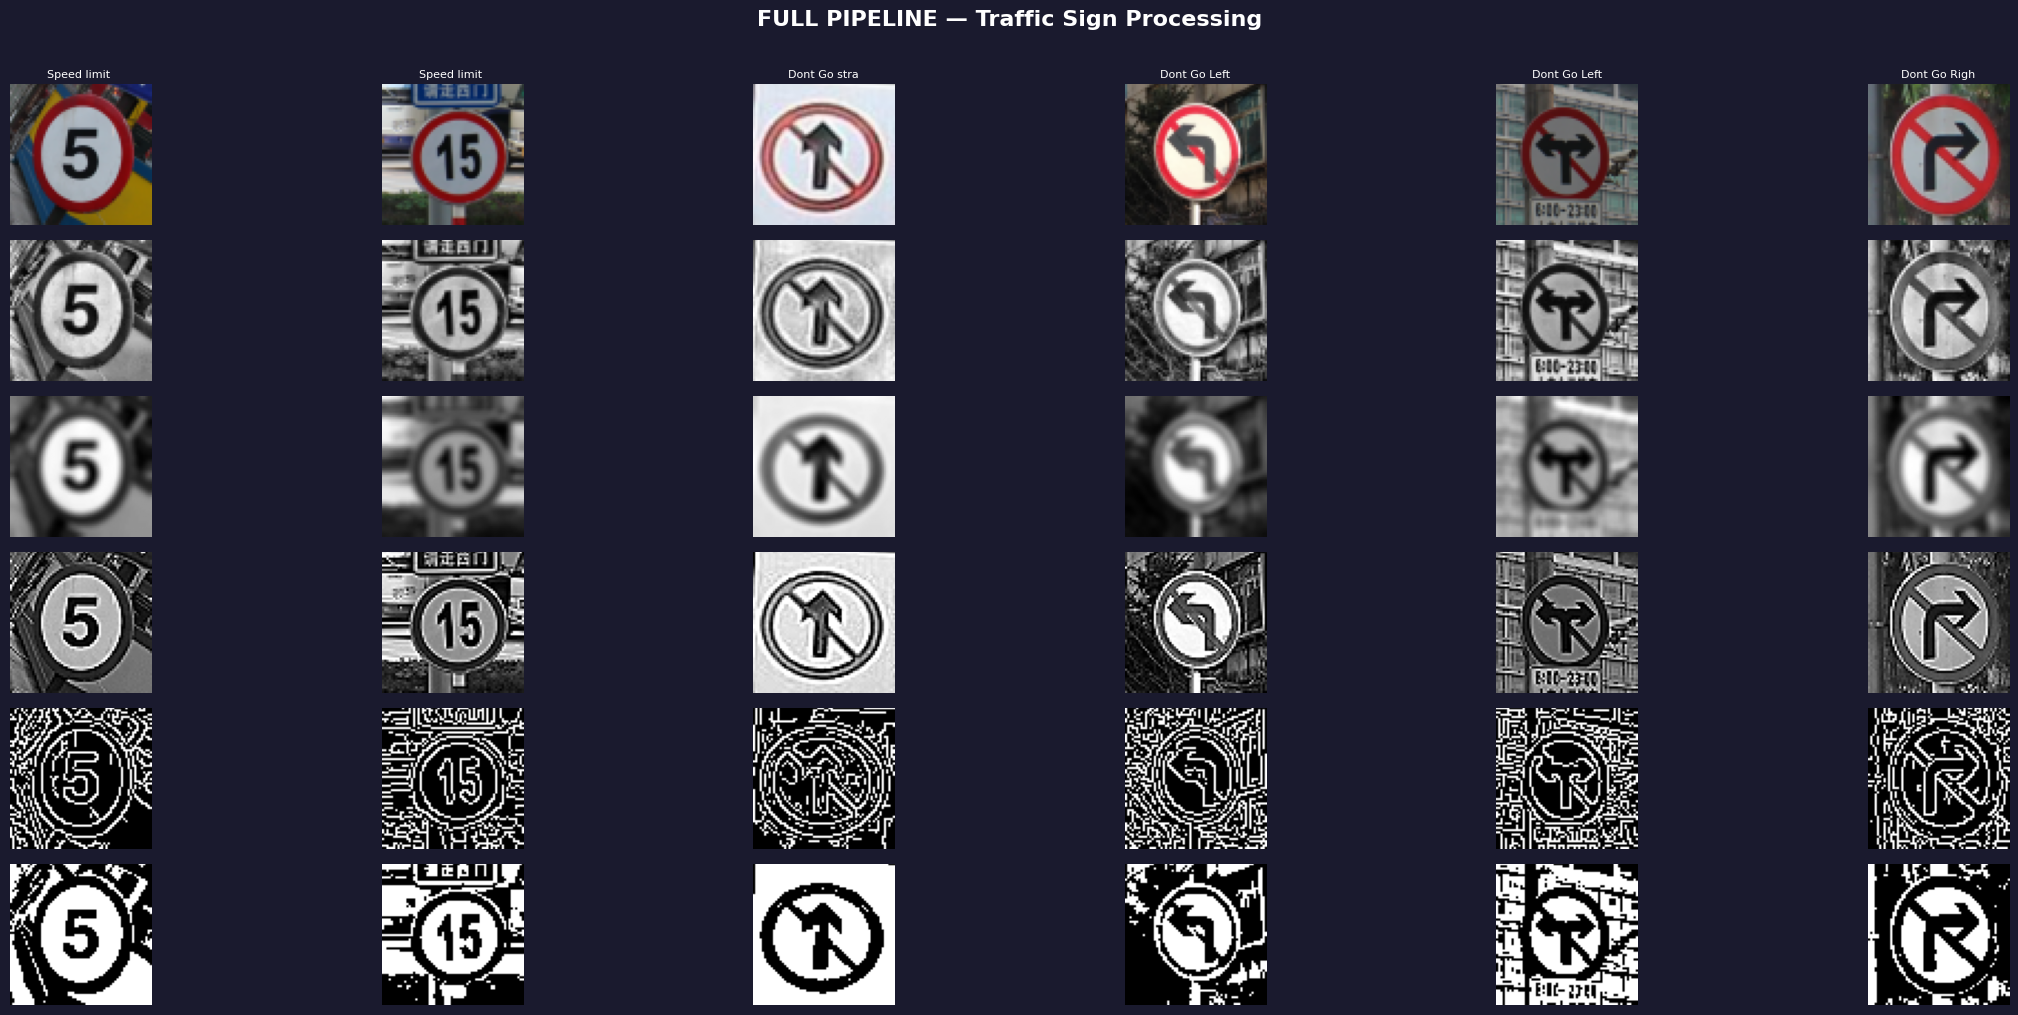

In [16]:
fig = plt.figure(figsize=(24, 10))
fig.patch.set_facecolor('#1a1a2e')

sample_classes = sorted(os.listdir(DATA_PATH))[:6]
n = len(sample_classes)
stages_labels = ['Original', 'CLAHE', 'Gaussian', 'Sharpened', 'Canny', 'Otsu Seg.']

for col, cls in enumerate(sample_classes):
    cls_dir  = os.path.join(DATA_PATH, cls)
    img_file = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png','.jpg','.ppm'))][0]
    p = os.path.join(cls_dir, img_file)
    rr = preprocess_image(p)
    if rr is None: continue

    ff = apply_filters(rr['gray'])
    ee = edge_and_segment(rr['enhanced'], rr['color'])

    stages_imgs = [rr['color'], rr['enhanced'],
                   ff['gaussian'], ff['sharpened'],
                   ee['canny'], ee['otsu']]
    cmaps_list  = [None, 'gray', 'gray', 'gray', 'gray', 'gray']

    cls_id   = int(cls) if cls.isdigit() else col
    cls_name = label_dict.get(cls_id, f'Class {cls}')

    for row, (img, cmap) in enumerate(zip(stages_imgs, cmaps_list)):
        ax = fig.add_subplot(6, n, row * n + col + 1)
        ax.imshow(img, cmap=cmap); ax.axis('off')
        if row == 0:
            ax.set_title(cls_name[:12], color='white', fontsize=8, pad=4)
        if col == 0:
            ax.set_ylabel(stages_labels[row], color='#aaa', fontsize=8,
                          rotation=0, labelpad=55, va='center')

fig.suptitle('FULL PIPELINE — Traffic Sign Processing',
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('/content/P5_full_report.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()